In [1]:
!pip install pandas==2.2.2
!pip install gspread scikit-learn pandas

In [2]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

In [3]:
import pandas as pd
import numpy as np

# Open the spreadsheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/14pMQzQwy2Dl9OIhS24hyJdX1sfEdVi9SeZfGuYaMKQ0/edit?usp=drive_link'
wb = gc.open_by_url(spreadsheet_url)
sheet = wb.get_worksheet(0)

# Load data into DataFrame
data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Original Data - Original Data:")
display(df.head())

Original Data - Original Data:


,text,label_specific,label_generic
0,Hi\n\n I am running the IR test...,human_legit,legit
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,human_legit,legit
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,human_legit,legit
3,"Hi Tony\nNot sure why it didn't work, but I ma...",human_legit,legit
4,Kindly suggest changes\n\n--------------------...,human_legit,legit


Vectorization + text length

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
# counts and analyzes each of the words that are common in each of the 4000 rows
vectors = vectorizer.fit_transform(df['text'])
# not necessarily vectorization, but counts each of the text lengths and makes a column for counting the text length (will be used later but decided to put it here)
df['text_length'] = df['text'].str.len()
display(df[['text', 'text_length']])

,text,text_length
0,Hi\n\n I am running the IR test...,207
1,\n\n\n\n\n\n\n\n\n\n\n\n\nSecurity Note: Trade...,698
2,\n\n\n\n\n\n\n\n\n\nTrade Me Offer RequestGene...,308
3,"Hi Tony\nNot sure why it didn't work, but I ma...",3171
4,Kindly suggest changes\n\n--------------------...,194
...,...,...
3995,"Hi Olivia, I hope this email finds you in good...",788
3996,"Dear Michael, I hope this email finds you well...",728
3997,"Hi Jessica, I hope this email finds you in goo...",763
3998,"Dear Benjamin, I hope this email finds you wel...",745


Standardization

In [5]:
from sklearn.preprocessing import StandardScaler
trainingData = vectors.toarray()
# saying how common each word is, attempting to see the correlation
scaler = StandardScaler().fit(trainingData)
scaled_data = scaler.transform(trainingData)
print(scaled_data)

[[-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]
 [-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]
 [-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]
 ...
 [-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]
 [-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]
 [-0.16351403 -0.08624078 -0.1275746  ... -0.02236627 -0.02236627
  -0.02236627]]


Dimension Reduction

In [6]:
from sklearn.decomposition import PCA
# n_components to capture 95% of the components
dimreduc = PCA(n_components=0.95)
dimreduc.fit(scaled_data)
# total amount of variance the dimension reduction function
cumulative_variance = np.cumsum(dimreduc.explained_variance_ratio_)
print(cumulative_variance)

[0.02408777 0.0404502  0.05652569 ... 0.9499043  0.94998741 0.9500704 ]


Training & Testing the Model

KNN Classification Training


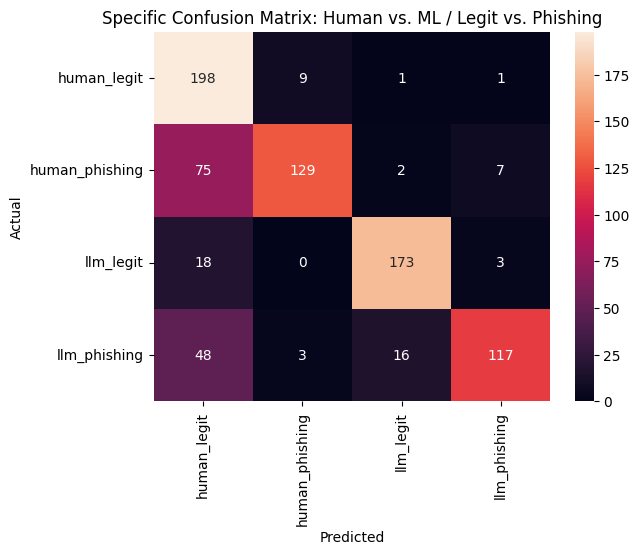

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
# creating a confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# training the data
print("KNN Classification Training")

# Recreate the original DataFrame 'df' from the 'data' variable.
# This addresses the KeyError by ensuring 'label_specific' column exists.
# The 'data' variable was loaded in a previous cell (4XIcOnpqTOc4) and contains the original spreadsheet data.
df = pd.DataFrame(data[1:], columns=data[0])

xPCA = dimreduc.transform(scaled_data)
# specific
y = df['label_specific']
x_train, x_test, y_train, y_test = train_test_split(xPCA, y, test_size = 0.2, random_state = 42)
# assigining the number of neighbors
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train, y_train)
y_pred = KNN.predict(x_test)
# analyzing the accuracy of the knn detection model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=KNN.classes_, yticklabels=KNN.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Specific Confusion Matrix: Human vs. ML / Legit vs. Phishing')
plt.show()

KNN Classification Training


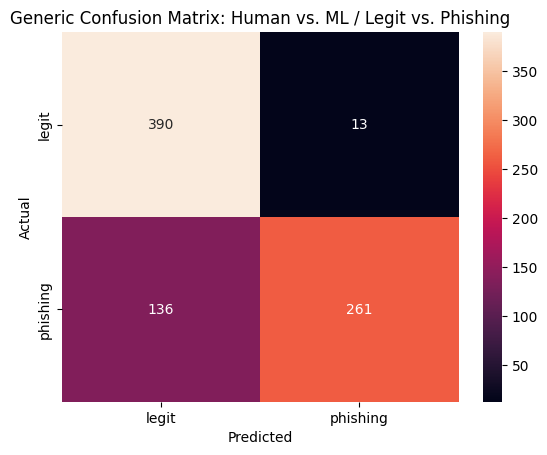

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
# creating a confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# training the data
print("KNN Classification Training")

# Recreate the original DataFrame 'df' from the 'data' variable.
# This addresses the KeyError by ensuring 'label_specific' column exists.
# The 'data' variable was loaded in a previous cell (4XIcOnpqTOc4) and contains the original spreadsheet data.
df = pd.DataFrame(data[1:], columns=data[0])

xPCA = dimreduc.transform(scaled_data)
# specific
y = df['label_generic']
x_train, x_test, y_train, y_test = train_test_split(xPCA, y, test_size = 0.2, random_state = 42)
# assigining the number of neighbors
KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(x_train, y_train)
y_pred = KNN.predict(x_test)
# analyzing the accuracy of the knn detection model
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=KNN.classes_, yticklabels=KNN.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Generic Confusion Matrix: Human vs. ML / Legit vs. Phishing')
plt.show()